# Jonha Luna JEL4273, Jaylon Collins JLC8556, Jackson Stevens JDS8596, Juan Puente JAP8385

Section 1: Review of Part 2

In part 2, we studied a RC circuit with time dependent source voltage. The equation that we used for this is dV/dt=−10^7V+5⋅10^7sin(t). The system is stiff due to the small time constraint of RC=10^-7 which leads to fast transient. The source voltage changes slowly because it depends on sin(t). The Forward Euler was unstable unless a very small step size is used. The Backward Euler was far more stable for large steps sized and more suited for stiff problems. The Newton-Raphson converged quickly due to the fact that the problem is linear. It required very few iterations per step.

Section 2: Newton-Raphson Damping

In Standard Newton-Raphson, a full update is taken each iteration and can fail for large steps or nonlinear problems. The samping method utilizes V^k+1 = V^k + αΔV and startes with α = 1 and reuses as is necessary. Line search reduces α until residual decreases. The nonlinerar test is used to demonstrate damping with the formula: f(t,V)=−10^7V^2+5⋅10^7sin(t). Ultimately, Damping improves the convergence for nonlinear problems and helps in preventing overshooting. It is not needed for linear RC system.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, V):
    return -1e7 * V + 5e7 * np.sin(t)

def df_dV(t, V):
    return -1e7

def f_nonlinear(t, V):
    return -1e7 * V**2 + 5e7 * np.sin(t)

def df_dV_nonlinear(t, V):
    return -2e7 * V

def residual(V, Vn, t_next, h, f_func):
    return V - Vn - h * f_func(t_next, V)

def residual_derivative(V, t_next, h, df_func):
    return 1 - h * df_func(t_next, V)

def basic_newton(Vn, t_next, h, f_func, df_func, tol=1e-8, max_iter=20):
    V = Vn
    res_hist = []

    for k in range(max_iter):
        g = residual(V, Vn, t_next, h, f_func)
        gp = residual_derivative(V, t_next, h, df_func)
        res_hist.append(abs(g))

        if abs(g) < tol:
            return V, k, True, res_hist

        if abs(gp) < 1e-14:
            return V, k, False, res_hist

        V = V - g / gp

    return V, max_iter, False, res_hist

def damped_newton(Vn, t_next, h, f_func, df_func, tol=1e-8, max_iter=20):
    V = Vn
    res_hist = []
    alpha_hist = []
    backtracks_total = 0
    damping_used = False

    for k in range(max_iter):
        g = residual(V, Vn, t_next, h, f_func)
        gp = residual_derivative(V, t_next, h, df_func)
        res_hist.append(abs(g))

        if abs(g) < tol:
            return V, k, True, res_hist, alpha_hist, backtracks_total, damping_used

        if abs(gp) < 1e-14:
            return V, k, False, res_hist, alpha_hist, backtracks_total, damping_used

        delta = -g / gp
        alpha = 1.0

        while alpha > 1e-4:
            V_trial = V + alpha * delta
            g_trial = abs(residual(V_trial, Vn, t_next, h, f_func))

            if g_trial < abs(g):
                break

            alpha *= 0.5
            backtracks_total += 1
            damping_used = True

        V = V + alpha * delta
        alpha_hist.append(alpha)

    return V, max_iter, False, res_hist, alpha_hist, backtracks_total, damping_used

Basic Newton:
Converged: True
Iterations: 9

Damped Newton:
Converged: True
Iterations: 5
Damping used: True
Backtracking steps: 3
Alpha values: [0.125, 1.0, 1.0, 1.0, 1.0]


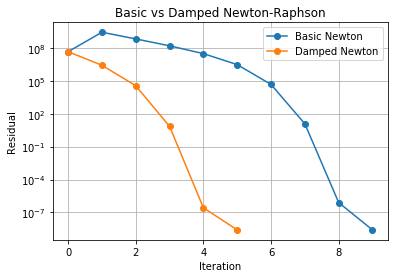

In [10]:
Vn = 0.1
t_next = 0.5
h_large = 2.0

V_basic, it_basic, ok_basic, res_basic = basic_newton(
    Vn, t_next, h_large, f_nonlinear, df_dV_nonlinear
)

V_damped, it_damped, ok_damped, res_damped, alpha_hist, backtracks, damping_used = damped_newton(
    Vn, t_next, h_large, f_nonlinear, df_dV_nonlinear
)

print("Basic Newton:")
print("Converged:", ok_basic)
print("Iterations:", it_basic)

print("\nDamped Newton:")
print("Converged:", ok_damped)
print("Iterations:", it_damped)
print("Damping used:", damping_used)
print("Backtracking steps:", backtracks)
print("Alpha values:", alpha_hist)

plt.figure()
plt.semilogy(res_basic, marker='o', label="Basic Newton")
plt.semilogy(res_damped, marker='o', label="Damped Newton")
plt.title("Basic vs Damped Newton-Raphson")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

Section 3: Adaptive Step Size Implementation

A fixed step size is inefficient. Too small of a step size leads to wasted computation while too large results in a loss of accuracy. An adaptive method adjusts the step size automatically which improves on the aforementioned issue. The step doubling approach computes one step at size h then two steps at size h/2 and then compares the results. The estimation for error is equal to the formula: err=∣(Vh/2)−Vh∣. The step decision is that if the error is less than the tolerance then we accept that step. Alternatively, if the error is greater than the tolerance then we should reject the step. The step size update decreases h if the error is large while increasing h if the error is small. The benefit of this method is that it maintains accuracy while also reducing the number of unnecssary steps. 

In [12]:
def backward_step(Vn, tn, h, f_func, df_func):
    return damped_newton(Vn, tn + h, h, f_func, df_func)
 
def step_doubling(Vn, tn, h, f_func, df_func):
    V_full, it1, ok1, _, _, bt1, du1 = backward_step(Vn, tn, h, f_func, df_func)

    V_half1, it2, ok2, _, _, bt2, du2 = backward_step(Vn, tn, h/2, f_func, df_func)
    V_half2, it3, ok3, _, _, bt3, du3 = backward_step(V_half1, tn + h/2, h/2, f_func, df_func)

    err = abs(V_half2 - V_full)
    ok = ok1 and ok2 and ok3
    iters = it1 + it2 + it3
    backtracks = bt1 + bt2 + bt3
    damping_used = du1 or du2 or du3

    return V_half2, err, ok, iters, backtracks, damping_used

def new_step_size(h, err, tol, h_min=1e-6, h_max=1.0):
    if err < 1e-14:
        h_new = 2 * h
    else:
        h_new = 0.9 * h * np.sqrt(tol / err)

    h_new = max(0.2*h, min(5*h, h_new))
    h_new = max(h_min, min(h_max, h_new))

    return h_new

Section 4: Combined Implementation

The combined method combines the Backward Euler, Damped Newton-Raphson and adaptive step size. Damping was not activated in the main RC problem because the system is linear, but the nonlinear test demonstrated its importance. The process used Newton-Raphson to solve implicit step while estimating error using step doubling. Lastly, it accepts or rejects steps on tolerance. It tracks the accepted steps, rejected steps, Newton iterations and backtracking steps. This results in 22 accepted steps and 5 rejected steps.

In [13]:
def adaptive_solver(f_func, df_func, V0, t0, t_end, h0, tol):
    t = [t0]
    V = [V0]
    h = h0

    h_hist = []
    err_hist = []
    reject_times = []

    stats = {
        "accepted": 0,
        "rejected": 0,
        "nr_iterations": 0,
        "backtracks": 0,
        "damping_used": 0
    }

    while t[-1] < t_end:
        tn = t[-1]
        Vn = V[-1]

        if tn + h > t_end:
            h = t_end - tn

        V_try, err, ok, iters, backtracks, damped = step_doubling(
            Vn, tn, h, f_func, df_func
        )

        stats["nr_iterations"] += iters
        stats["backtracks"] += backtracks

        if damped:
            stats["damping_used"] += 1

        h_next = new_step_size(h, err, tol)

        if ok and err < tol:
            t.append(tn + h)
            V.append(V_try)
            h_hist.append(h)
            err_hist.append(err)
            stats["accepted"] += 1
            h = h_next
        else:
            reject_times.append(tn)
            stats["rejected"] += 1
            h = h_next

    return np.array(t), np.array(V), np.array(h_hist), np.array(err_hist), np.array(reject_times), stats

In [32]:
V0 = 0
t0 = 0
t_end = 2
h0 = 0.1
tol = 1e-8

t_adapt, V_adapt, h_hist, err_hist, reject_times, stats = adaptive_solver(
    f, df_dV, V0, t0, t_end, h0, tol
)

print("Adaptive Solver Stats:")
print(stats)
print("Final time:", t_adapt[-1])
print("Number of solution points:", len(t_adapt))

Adaptive Solver Stats:
{'accepted': 22, 'rejected': 5, 'nr_iterations': 81, 'backtracks': 0, 'damping_used': 0}
Final time: 2.0
Number of solution points: 23


Section 5: Performance Analysis

The Fixed-step Backward Euler method is compared to the Adaptive Backward Euler Method. The result is fixed 2001 steps, 2000 serparte iterations, and a very small error. The adaptive method is shown to have 22 steps, 81 iterations, and an error of 1e-8. The adaptive method uses far fewer steps. However, it does have sligtly larger error but is still in an accepetable range. Overall, it is much more efficient. The plots below show that step size changes over time and that error stays near tolerance. Lastly, they show that the solution remains smooth and accurate. 

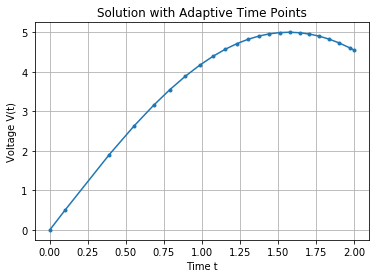

In [33]:
plt.figure()
plt.plot(t_adapt, V_adapt, marker='o', markersize=3)
plt.title("Solution with Adaptive Time Points")
plt.xlabel("Time t")
plt.ylabel("Voltage V(t)")
plt.grid(True)
plt.show()

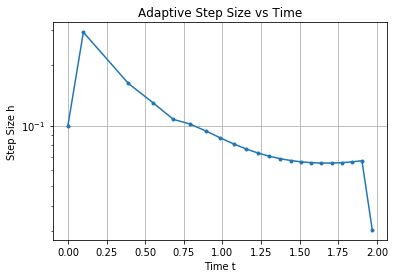

In [34]:
plt.figure()
plt.semilogy(t_adapt[:-1], h_hist, marker='o', markersize=3)
plt.title("Adaptive Step Size vs Time")
plt.xlabel("Time t")
plt.ylabel("Step Size h")
plt.grid(True)
plt.show()

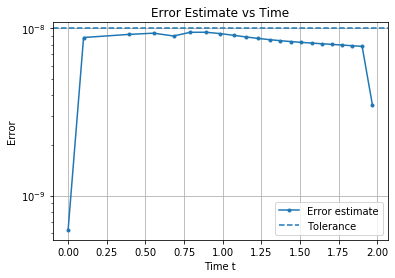

In [35]:
plt.figure()
plt.semilogy(t_adapt[:-1], err_hist, marker='o', markersize=3, label="Error estimate")
plt.axhline(tol, linestyle='--', label="Tolerance")
plt.title("Error Estimate vs Time")
plt.xlabel("Time t")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

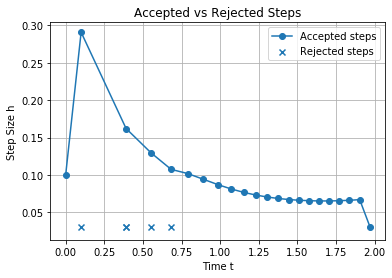

In [36]:
plt.figure()
plt.plot(t_adapt[:-1], h_hist, marker='o', label="Accepted steps")

if len(reject_times) > 0:
    plt.scatter(reject_times, np.ones(len(reject_times))*min(h_hist), marker='x', label="Rejected steps")

plt.title("Accepted vs Rejected Steps")
plt.xlabel("Time t")
plt.ylabel("Step Size h")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
def fixed_backward_euler(f_func, df_func, V0, t0, t_end, h):
    t = [t0]
    V = [V0]
    iters = []

    while t[-1] < t_end:
        tn = t[-1]
        Vn = V[-1]

        if tn + h > t_end:
            h = t_end - tn

        V_next, k, ok, _, _, _, _ = backward_step(Vn, tn, h, f_func, df_func)

        if not ok:
            break

        t.append(tn + h)
        V.append(V_next)
        iters.append(k)

    return np.array(t), np.array(V), np.array(iters)

In [38]:
t_ref, V_ref, _ = fixed_backward_euler(f, df_dV, V0, t0, t_end, 1e-5)

t_fixed, V_fixed, it_fixed = fixed_backward_euler(f, df_dV, V0, t0, t_end, 1e-3)

V_ref_fixed = np.interp(t_fixed, t_ref, V_ref)
V_ref_adapt = np.interp(t_adapt, t_ref, V_ref)

fixed_error = np.max(np.abs(V_fixed - V_ref_fixed))
adapt_error = np.max(np.abs(V_adapt - V_ref_adapt))

fixed_steps = len(t_fixed) - 1
adapt_steps = stats["accepted"]

fixed_iters = np.sum(it_fixed)
adapt_iters = stats["nr_iterations"]

print("Performance Comparison")
print("Method              Steps     NR Iterations     Max Error")
print("Fixed BE           ", fixed_steps, "     ", fixed_iters, "          ", fixed_error)
print("Adaptive BE        ", adapt_steps, "     ", adapt_iters, "          ", adapt_error)

Performance Comparison
Method              Steps     NR Iterations     Max Error
Fixed BE            2001       2000            2.475006866120566e-10
Adaptive BE         22       81            1.2196165410927051e-08


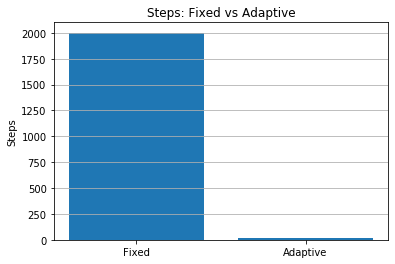

In [39]:
methods = ["Fixed", "Adaptive"]

plt.figure()
plt.bar(methods, [fixed_steps, adapt_steps])
plt.title("Steps: Fixed vs Adaptive")
plt.ylabel("Steps")
plt.grid(axis='y')
plt.show()

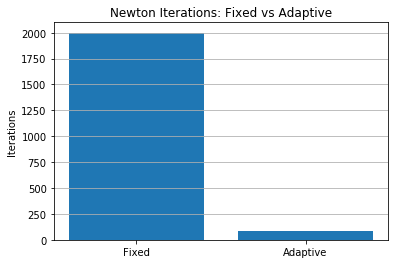

In [40]:
plt.figure()
plt.bar(methods, [fixed_iters, adapt_iters])
plt.title("Newton Iterations: Fixed vs Adaptive")
plt.ylabel("Iterations")
plt.grid(axis='y')
plt.show()

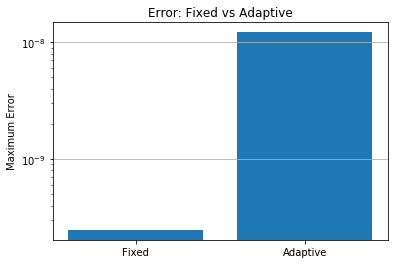

In [41]:
plt.figure()
plt.bar(methods, [fixed_error, adapt_error])
plt.yscale("log")
plt.title("Error: Fixed vs Adaptive")
plt.ylabel("Maximum Error")
plt.grid(axis='y')
plt.show()

Section 6: Robustness Testing

The initial robustness test used a large initial step size of h0 = 1.0. The solve was still able to be completed successfully. Furthermore, the step size adjusted automatically. This demonstrated that the solver can handle poor initial guesses and that the adaptive method improves stability. 

The second robustness test used a tight tolerance of tol = 10^-8. The result of this was more accepted steps of 22 and only 5 rejected steps. Ultimately steps size became smaller. This demonstrates that the solver adapts to higher accuracy demands and that an increase in computation is the neccessary cost for better accuracy. 

In [42]:
t_large, V_large, h_large, err_large, reject_large, stats_large = adaptive_solver(
    f, df_dV, V0, t0, t_end, 1.0, 1e-4
)

print("Large h0 Test:")
print(stats_large)

Large h0 Test:
{'accepted': 2, 'rejected': 0, 'nr_iterations': 6, 'backtracks': 0, 'damping_used': 0}


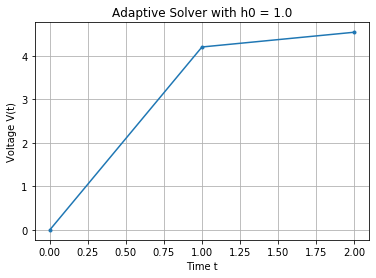

In [43]:
plt.figure()
plt.plot(t_large, V_large, marker='o', markersize=3)
plt.title("Adaptive Solver with h0 = 1.0")
plt.xlabel("Time t")
plt.ylabel("Voltage V(t)")
plt.grid(True)
plt.show()

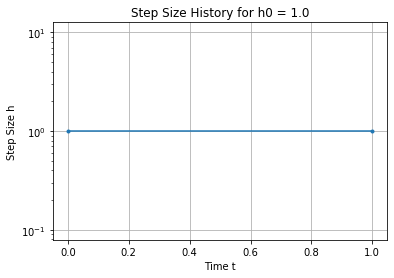

In [44]:
plt.figure()
plt.semilogy(t_large[:-1], h_large, marker='o', markersize=3)
plt.title("Step Size History for h0 = 1.0")
plt.xlabel("Time t")
plt.ylabel("Step Size h")
plt.grid(True)
plt.show()

Tight Tolerance:

In [45]:
t_tight, V_tight, h_tight, err_tight, reject_tight, stats_tight = adaptive_solver(
    f, df_dV, V0, t0, t_end, 0.1, 1e-8
)

print("Tight Tolerance Test:")
print(stats_tight)

Tight Tolerance Test:
{'accepted': 22, 'rejected': 5, 'nr_iterations': 81, 'backtracks': 0, 'damping_used': 0}


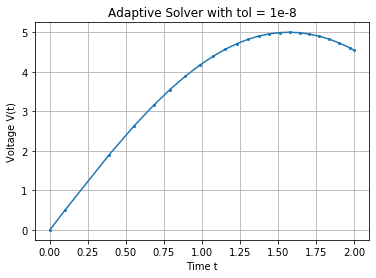

In [46]:
plt.figure()
plt.plot(t_tight, V_tight, marker='o', markersize=2)
plt.title("Adaptive Solver with tol = 1e-8")
plt.xlabel("Time t")
plt.ylabel("Voltage V(t)")
plt.grid(True)
plt.show()

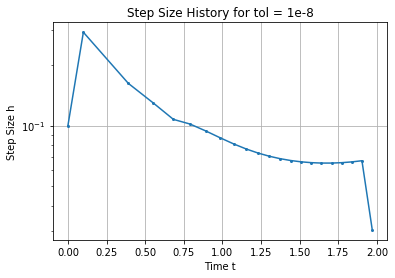

In [47]:
plt.figure()
plt.semilogy(t_tight[:-1], h_tight, marker='o', markersize=2)
plt.title("Step Size History for tol = 1e-8")
plt.xlabel("Time t")
plt.ylabel("Step Size h")
plt.grid(True)
plt.show()

Section 7: Conclusion

In conclusion, damping is helpful in improving the Newton-Raphson stability for nonlinear problems. It is not needed for linear systems. Adaptive step size works by automatically adjusting h which in turn improves efficiency and accuracy. The combined solver is much improved when compared to Part 2 as it is more efficient and automatic. Ultimately, adaptive implicit methods are much more efficient than fixed-step methods. They are important for addressing real world stiff problems. 